In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, ConcatDataset
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image
from tqdm import tqdm
from torchvision import transforms

from skimage import io
import sys
# from umap import UMAP
import joblib
from datetime import datetime

# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae, BetaVAE32
from core.dataset import TIFFDataset, NormTIFFDataset
from utils.feature_analysis import UMAP_train, dataloader_model_latents,kmeans_cluster,DBSCAN_cluster
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot



In [ ]:
data_str = 'vin_pax_zyx_act_wholecell'
pro_str = 'pax_wholecell_correctloader'
main_ch = 1
ctrl_y_str = 'ctrl_y'
input_ps = 32
latent_dim_array = [8,12,16]
BN_flag = True
dropout_flag = True
epochs = int(10000)
lr = 1e-4
eps = 3
min_samples = 5
kmeans_num_clusters = 6
loss_norm_flag = 0

dir_list = [
'/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/tiff_patches32_40p_20250919_0948',
'/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_gridonly_wholecell_pslocation00/tiff_patches32_40p_20250919_1005',    
]




In [ ]:
root_dir = '/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323'
czi_base = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data'
analysis_base = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/'


AE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder_fc): Sequential(
    (0): Linear(in_features=2048, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=8, bias=True)
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=8, out_features=1024

In [ ]:

transform = transforms.Compose([transforms.ToTensor()])

datasets = [
    TIFFDataset(root_dir=dir_path, label=label, transform=transform)
    for label, dir_path in enumerate(dir_list)
]

combined_dataset = ConcatDataset(datasets)

# Split dataset into training and validation sets
train_size = int(0.8 * len(combined_dataset))
val_size = len(combined_dataset) - train_size
train_dataset, val_dataset = random_split(combined_dataset, [train_size, val_size],generator=torch.Generator().manual_seed(42))
whole_data_loader = DataLoader(combined_dataset, batch_size=128, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)


to_save = {
    "train_loader": train_loader,
    "val_loader": val_loader,
    "train_dataset": train_dataset,
    "val_dataset": val_dataset,
    "whole_data_loader": whole_data_loader,
    "combined_dataset": combined_dataset,    
}

joblib.load(to_save, "../results/vindata_pax_wholecell_dataset_train_val_loader_normp1p998.pkl")

# # loaded = joblib.load("../results/vindata_pax_wholecell_dataset_train_val_loader.pkl")
# train_loader = loaded['train_loader']
# val_loader = loaded['val_loader']
# whole_data_loader = loaded['whole_data_loader']
# train_dataset = loaded['train_dataset']
# val_dataset = loaded['val_dataset']
# combined_dataset = loaded['combined_dataset']



In [ ]:
# total_sum_sq = 0.0
# total_sum = 0.0
# n_total = 0

# for images, _ in whole_data_loader:
#     images = images.to(torch.float32)
#     total_sum += (images).sum().item()
#     total_sum_sq += (images ** 2).sum().item()
#     n_total += images.numel()

# mean_square = total_sum_sq / n_total
# mean = total_sum / n_total
# print("Mean square of all pixels:", mean_square)


# to_save = {
#     "mean": mean,
#     "mean_square": mean_square}

# joblib.dump(to_save,'../results/vindata_pax_wholecell_mean_mean_square.pkl')


loaded = joblib.load("../results/vindata_pax_wholecell_mean_mean_square.pkl")
data_mean = loaded['mean']
data_mean_square = loaded['mean_square']


In [ ]:

latent_dim = 8
mse_loss = nn.MSELoss(reduction='none')
ae.eval()
train_latents = []
train_images = []
train_recons = []
train_losses = []
train_group_ids = []



for x, group_id, img_path in train_loader:
    x = x.to(device)
    recon, z = ae(x)

    # store latents
    train_latents.append(z.cpu())

    # store images
    train_images.append(x.cpu())
    train_recons.append(recon.cpu())

    # compute loss
    loss_per_pixel = mse_loss(recon, x)         
    # print(loss_per_pixel.shape)               # [B, 1, 32, 32]
    loss_per_sample = loss_per_pixel.view(x.size(0), -1).mean(dim=1)   # [B]

    train_losses.append(loss_per_sample.cpu())


    train_group_ids.append(group_id)



In [11]:
train_recons = torch.cat(train_recons, dim=0)
train_images = torch.cat(train_images, dim=0)
train_group_ids = torch.cat(train_group_ids,dim=0)
train_latents = torch.cat(train_latents, dim=0)
train_losses = torch.cat(train_losses,dim=0)

In [13]:
latent_dim = 8
mse_loss = nn.MSELoss(reduction='none')
ae.eval()
val_latents = []
val_images = []
val_recons = []
val_losses = []
val_group_ids = []


for x, group_id,img_path in val_loader:
    x = x.to(device)
    recon, z = ae(x)

    # store latents
    val_latents.append(z.cpu())

    # store images
    val_images.append(x.cpu())
    val_recons.append(recon.cpu())

    # compute loss
    loss_per_pixel = mse_loss(recon, x)         
    # print(loss_per_pixel.shape)               # [B, 1, 32, 32]
    loss_per_sample = loss_per_pixel.view(x.size(0), -1).mean(dim=1)   # [B]

    val_losses.append(loss_per_sample.cpu())


    val_group_ids.append(group_id)



In [14]:
val_recons = torch.cat(val_recons, dim=0)
val_images = torch.cat(val_images, dim=0)
val_group_ids = torch.cat(val_group_ids,dim=0)
val_latents = torch.cat(val_latents, dim=0)
val_losses = torch.cat(val_losses,dim=0)

In [28]:
image_cy = torch.concat([train_images,val_images],dim=0)
recon_cy = torch.concat([train_recons,val_recons],dim=0)

In [15]:
val_recons.shape

torch.Size([4732, 1, 32, 32])

/tmp/ipykernel_119925/2906582416.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([train_loss_group0, train_loss_group1,val_loss_group0,val_loss_group1],


(0.0, 0.03)

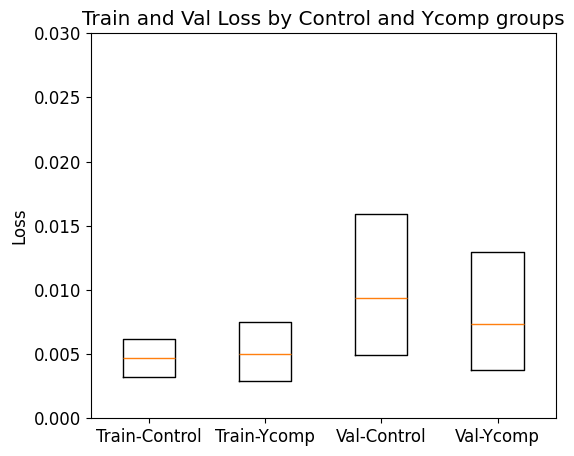

In [71]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})

# select losses for each group
train_loss_group0 = train_losses[train_group_ids == 0].detach().numpy()
train_loss_group1 = train_losses[train_group_ids == 1].detach().numpy()
val_loss_group0 = val_losses[val_group_ids == 0].detach().numpy()
val_loss_group1 = val_losses[val_group_ids == 1].detach().numpy()

# create boxplot
plt.figure(figsize=(6, 5))
plt.boxplot([train_loss_group0, train_loss_group1,val_loss_group0,val_loss_group1],
            labels=["Train-Control", "Train-Ycomp","Val-Control", "Val-Ycomp"],
            whiskerprops=dict(linewidth=0),
            capprops=dict(linewidth=0),
            flierprops=dict(marker='')  # remove outliers         # remove caps
            )

plt.ylabel("Loss")
plt.title("Train and Val Loss by Control and Ycomp groups")
# plt.grid(axis='y')
plt.ylim(0,0.03)


/tmp/ipykernel_119925/805574029.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


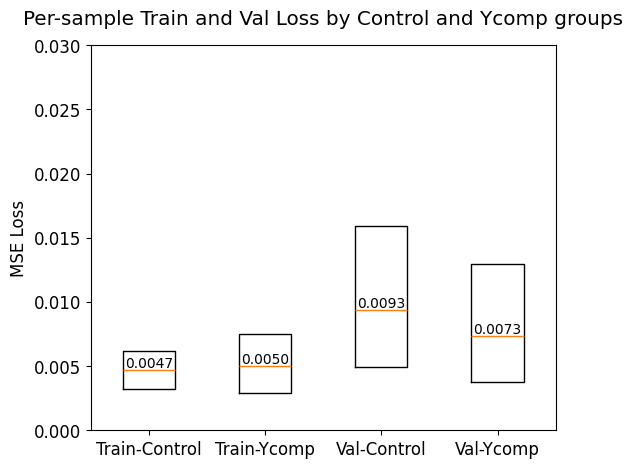

In [75]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})

# select losses for each group
train_loss_group0 = train_losses[train_group_ids == 0].detach().numpy()
train_loss_group1 = train_losses[train_group_ids == 1].detach().numpy()
val_loss_group0 = val_losses[val_group_ids == 0].detach().numpy()
val_loss_group1 = val_losses[val_group_ids == 1].detach().numpy()

data = [train_loss_group0, train_loss_group1, val_loss_group0, val_loss_group1]
labels = ["Train-Control", "Train-Ycomp", "Val-Control", "Val-Ycomp"]

plt.figure(figsize=(6, 5))
bp = plt.boxplot(
    data,
    labels=labels,
    whiskerprops=dict(linewidth=0),
    capprops=dict(linewidth=0),
    flierprops=dict(marker='')
)

plt.ylabel("MSE Loss")
plt.title("Per-sample Train and Val Loss by Control and Ycomp groups", pad=15)
plt.ylim(0, 0.03)

# --- Add median labels ---
for i, median in enumerate(bp['medians']):
    # median line endpoints
    x, y = median.get_xdata(), median.get_ydata()
    median_y = y[0]     # median value
    median_x = x.mean() # center of the median line
    
    plt.text(
        median_x, median_y,
        f"{median_y:.4f}",
        ha='center', va='bottom',
        fontsize=10,
        color='black'
    )

plt.show()


/tmp/ipykernel_119925/1958474408.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


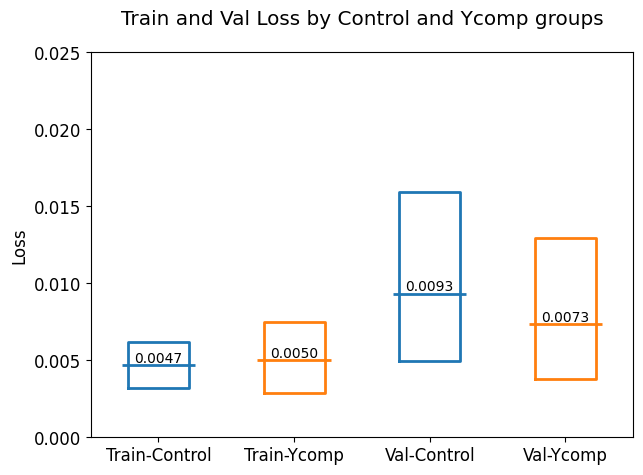

In [87]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'font.size': 12})

# ---------------------------
#  Prepare group loss arrays
# ---------------------------
train_loss_group0 = train_losses[train_group_ids == 0].detach().numpy()
train_loss_group1 = train_losses[train_group_ids == 1].detach().numpy()
val_loss_group0   = val_losses[val_group_ids == 0].detach().numpy()
val_loss_group1   = val_losses[val_group_ids == 1].detach().numpy()

data = [train_loss_group0, train_loss_group1, val_loss_group0, val_loss_group1]
labels = ["Train-Control", "Train-Ycomp", "Val-Control", "Val-Ycomp"]

# ---------------------------
#  Create the boxplot
# ---------------------------
plt.figure(figsize=(7, 5))

bp = plt.boxplot(
    data,
    labels=labels,
    whiskerprops=dict(linewidth=0),  # no whiskers
    capprops=dict(linewidth=0),      # no caps
    flierprops=dict(marker=''),      # no outliers
    patch_artist=False               # OUTLINES ONLY, not filled
)

plt.ylabel("Loss")
plt.title("Train and Val Loss by Control and Ycomp groups", pad=20)
plt.ylim(0, 0.025)

# ---------------------------
#  Color only the outlines
# ---------------------------
colors = ['#1f77b4', '#ff7f0e']  # Control (blue), Ycomp (orange)
group_colors = [colors[0], colors[1], colors[0], colors[1]]

for box, color in zip(bp['boxes'], group_colors):
    box.set_color(color)
    box.set_linewidth(2)
# ---------------------------
#  Extend median lines
# ---------------------------
extend_ratio = 0.1   # 10% longer on each side

for median in bp['medians']:
    x_vals = median.get_xdata()

    # current endpoints
    x_left, x_right = x_vals[0], x_vals[1]

    # compute extension
    width = x_right - x_left
    extension = width * extend_ratio

    # update the median line x-range
    median.set_xdata([x_left - extension, x_right + extension])

# Optionally color median lines to match box outline
for median, color in zip(bp['medians'], group_colors):
    median.set_color(color)
    median.set_linewidth(2)

# ---------------------------
#  Add median labels
# ---------------------------
for i, median in enumerate(bp['medians']):
    x_vals, y_vals = median.get_xdata(), median.get_ydata()
    median_y = y_vals[0]
    median_x = np.mean(x_vals)

    plt.text(
        median_x, median_y,
        f"{median_y:.4f}",
        ha='center', va='bottom',
        fontsize=10
    )

plt.show()


In [20]:
latent_cy = torch.concat([train_latents,val_latents],dim=0)

In [22]:
latent_cy_numpy = latent_cy.detach().numpy()

In [23]:
latent_cy_numpy.shape

(23656, 8)

In [24]:
latents_lat8_2d = UMAP_train(latent_cy_numpy, root_dir,'trainval_vin_pax_zyx_act_data_Pax_AE_lat8only_UMAP2')

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/tmp/ipykernel_333107/2530157147.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  plt.scatter(


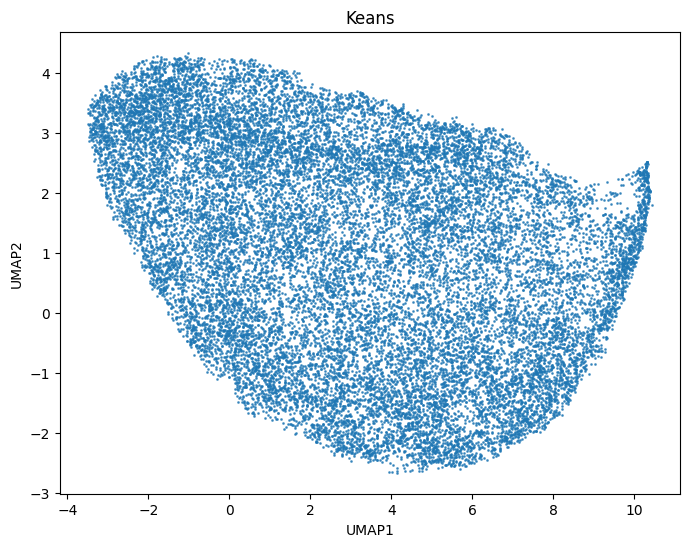

In [25]:
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(8, 6))

plt.scatter(
    latents_lat8_2d[:, 0],
    latents_lat8_2d[:, 1],    
    cmap='tab10',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=10
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Keans")

plt.show()


In [26]:
kmeans_num_clusters=20
kmeans, kmeans_labels = kmeans_cluster(latent_cy_numpy, kmeans_num_clusters, root_dir,'trainval_vindata_pax_AE_lat8_trainval42_kmeans')



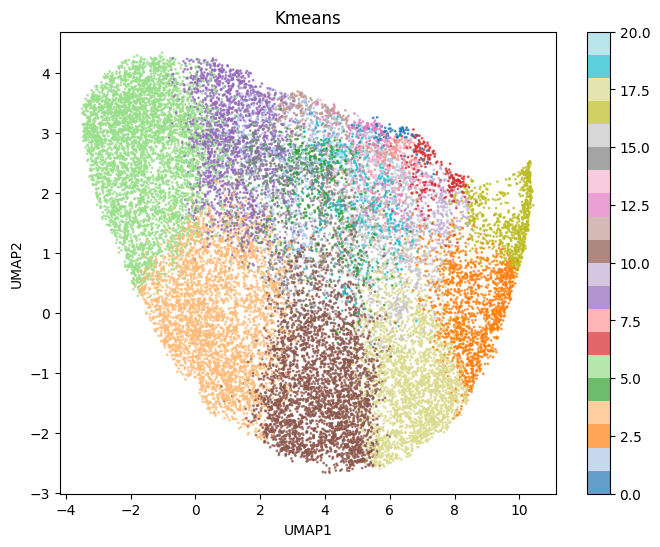

In [27]:
import matplotlib.pyplot as plt

filtered_colors = kmeans_labels


fig = plt.figure(figsize=(8, 6))

plt.scatter(
    latents_lat8_2d[:, 0],
    latents_lat8_2d[:, 1],
    c=filtered_colors,
    cmap='tab20',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=20
)

cbar = plt.colorbar()
# cbar.set_ticks(list(group_label_to_color.values()))
# cbar.set_ticklabels(list(group_label_to_color.keys()))
# cbar.ax.set_ylim(0,4)

# plt.xlim(-4,11)
# plt.ylim(-3,4.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Kmeans")

plt.show()


In [30]:
kmeans_labels.shape[0]

23656

In [36]:
# image_cy
# recon_cy 
# kmeans_labels

group_dir = os.path.join(root_dir,'groups20kmeans')
os.makedirs(group_dir,exist_ok=True)
for cind in range(0,20):
    img_dir = os.path.join(group_dir,'img_C'+str(cind).zfill(2))
    recon_dir = os.path.join(group_dir,'rec_C'+str(cind).zfill(2))
    os.makedirs(img_dir,exist_ok=True)
    os.makedirs(recon_dir,exist_ok=True)


for ind in range(0, kmeans_labels.shape[0]):
    cind = kmeans_labels[ind]
    image = image_cy[ind,:,:,:].detach().numpy().squeeze()
    recon = recon_cy[ind,:,:,:].detach().numpy().squeeze()
    
    raw_patch_img_filename = 'rawimg_'+str(ind).zfill(5)+'.tif'    
    tiff.imwrite(
        os.path.join(os.path.join(group_dir,'img_C'+str(cind).zfill(2)),raw_patch_img_filename),
        image.astype(np.float32),
        imagej=True,              # Write ImageJ metadata block
        metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
    )

    recon_patch_img_filename = 'recon_'+str(ind).zfill(5)+'.tif'    
    tiff.imwrite(
        os.path.join(os.path.join(group_dir,'rec_C'+str(cind).zfill(2)),recon_patch_img_filename),
        recon.astype(np.float32),
        imagej=True,              # Write ImageJ metadata block
        metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
    )
    



In [34]:
cind = kmeans_labels[ind]

In [35]:
cind

8